In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

os.chdir("../src")
os.getcwd()

from simulator.gca import Maxflow2GCA

%load_ext autoreload
%autoreload 2

/home/flyingleafe/Job/Clique/simple-eigentrust/python/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def graph_balances_and_credit_limits(G):
    n = G.number_of_nodes()
    balances = np.zeros(n)
    limits = np.zeros(n)

    for node, dd in G.nodes(data=True):
        balances[node] = dd["state"].balance
        limits[node] = dd["state"].credit_limit

    return balances, limits


def plot_balances_and_credit_limits(balances, limits):
    assert len(balances) == len(limits)
    x = np.arange(len(balances))
    plt.bar(x, balances, label='Available balances')
    plt.bar(x, limits, bottom=balances, label='Credit limits')
    plt.legend()
    plt.show()

In [3]:
graph = nx.barabasi_albert_graph(1000, 2, seed=42)
num_edges = graph.number_of_edges()
capacities = list(np.random.randint(1, 10000, num_edges))
balances = {node: np.random.randint(1, 100000) for node in graph.nodes}

for edge in graph.edges:
    graph.edges[edge]["capacity"] = capacities.pop()

gca = Maxflow2GCA(graph, balance_distribution=balances)
records = gca.run_simulation(10)


                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 10, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (10, 0, 1, 1)


Initializing configurations: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 718.33it/s]

Execution Method: single_proc_exec



Flattening results:   9%|████████████                                                                                                                         | 1/11 [00:00<00:00, 476.52it/s]

Total execution time: 0.67s


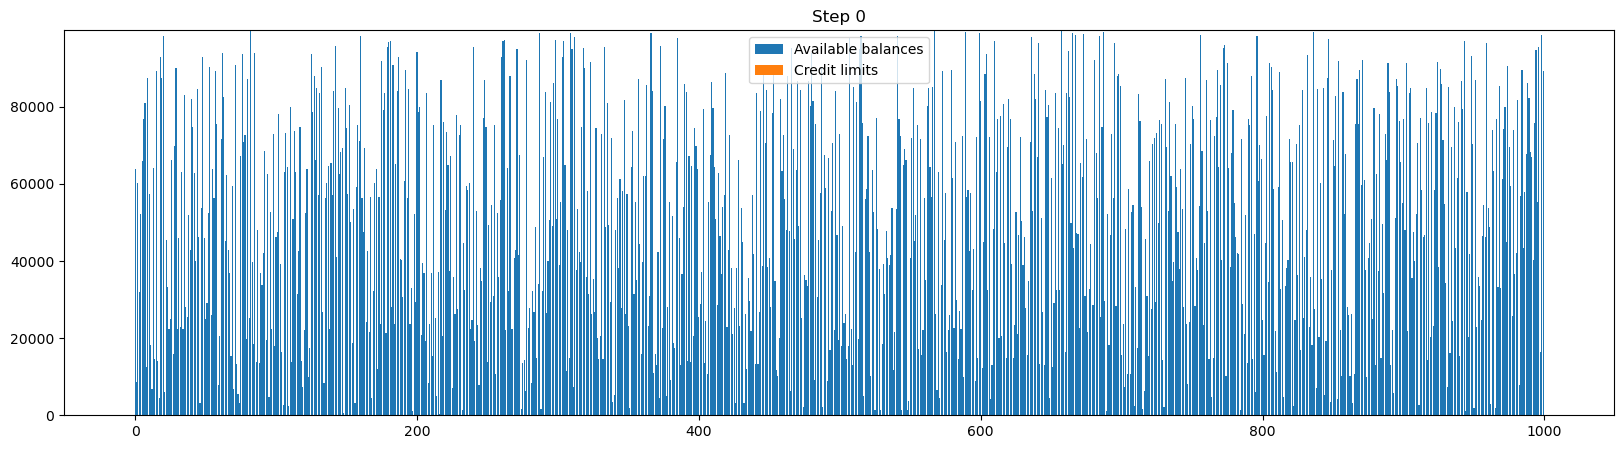

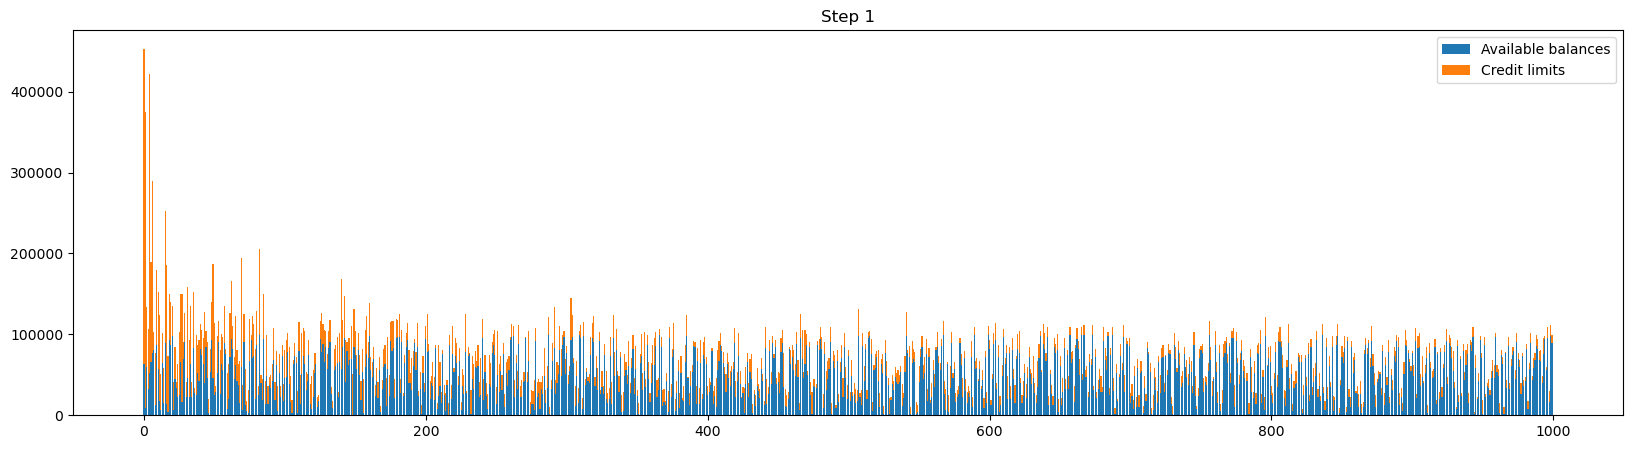

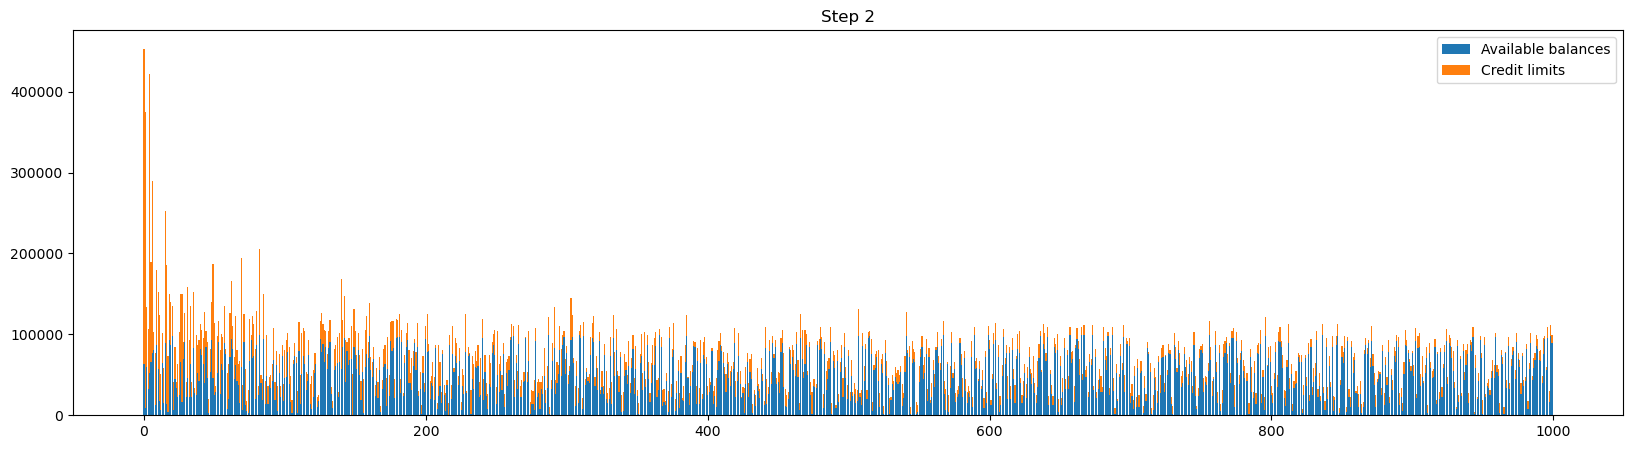

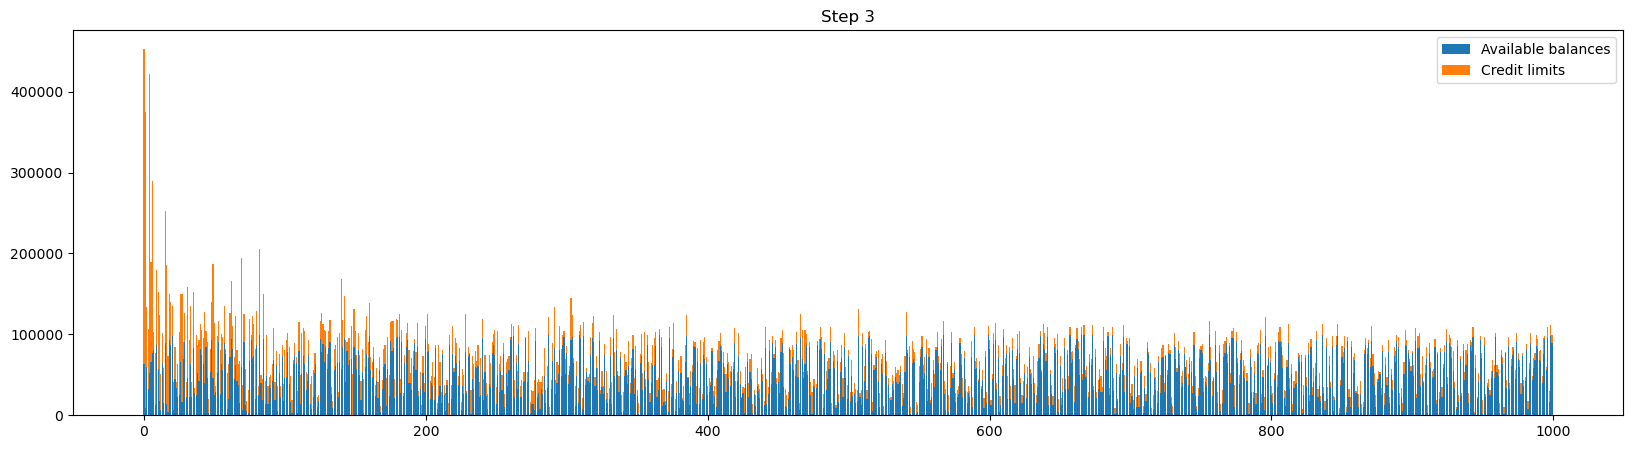

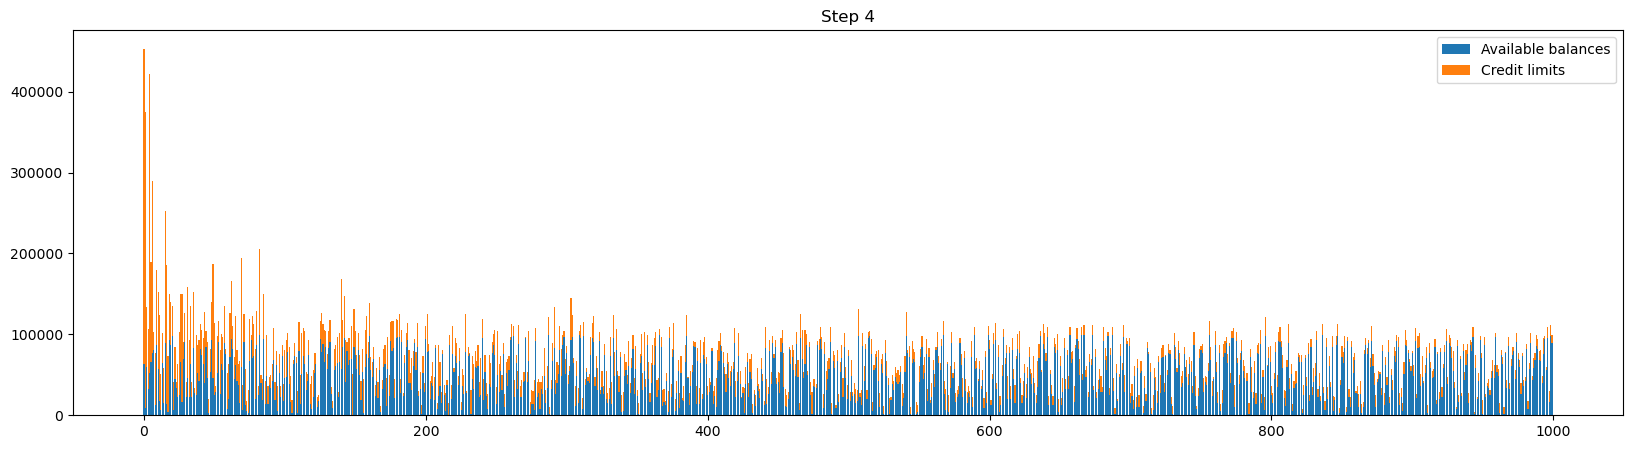

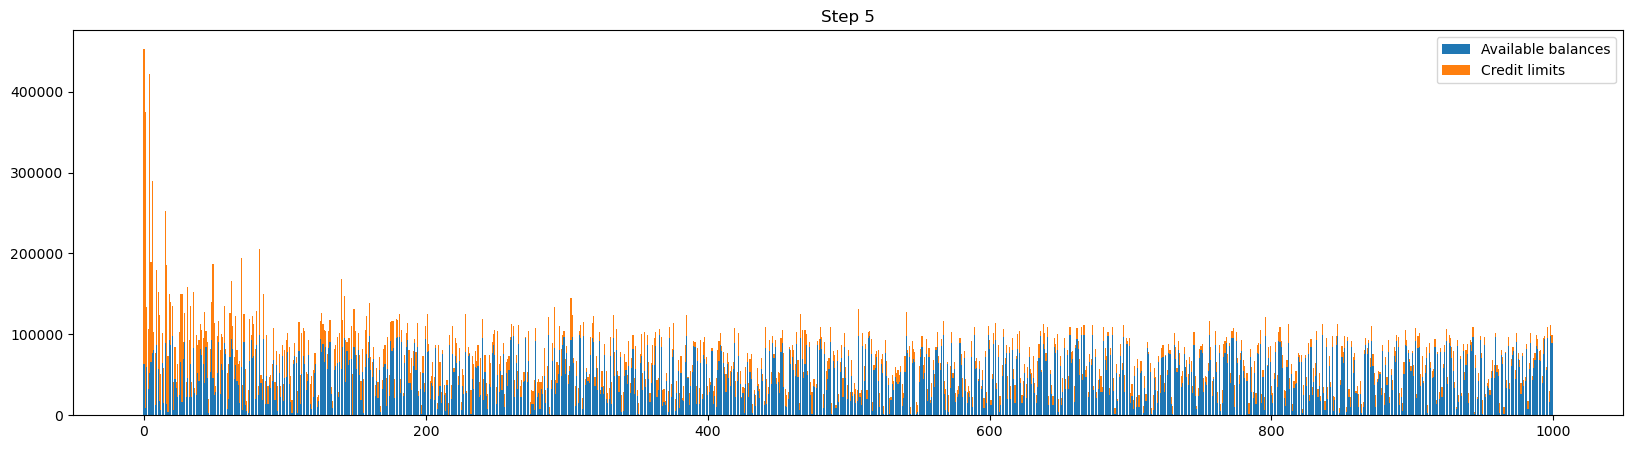

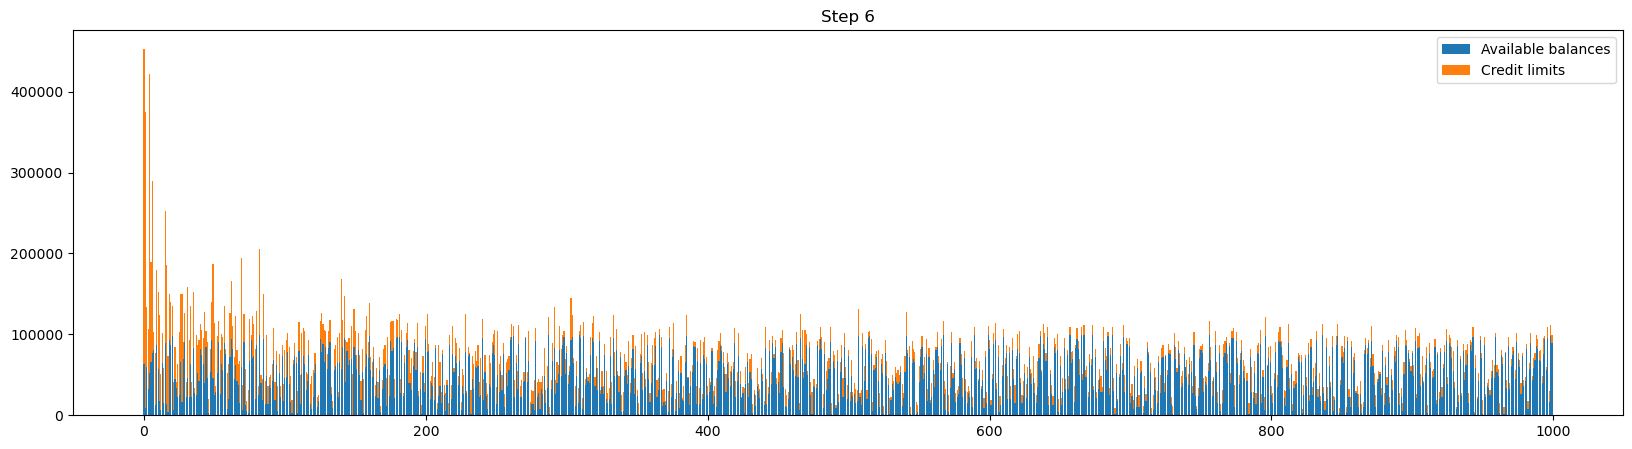

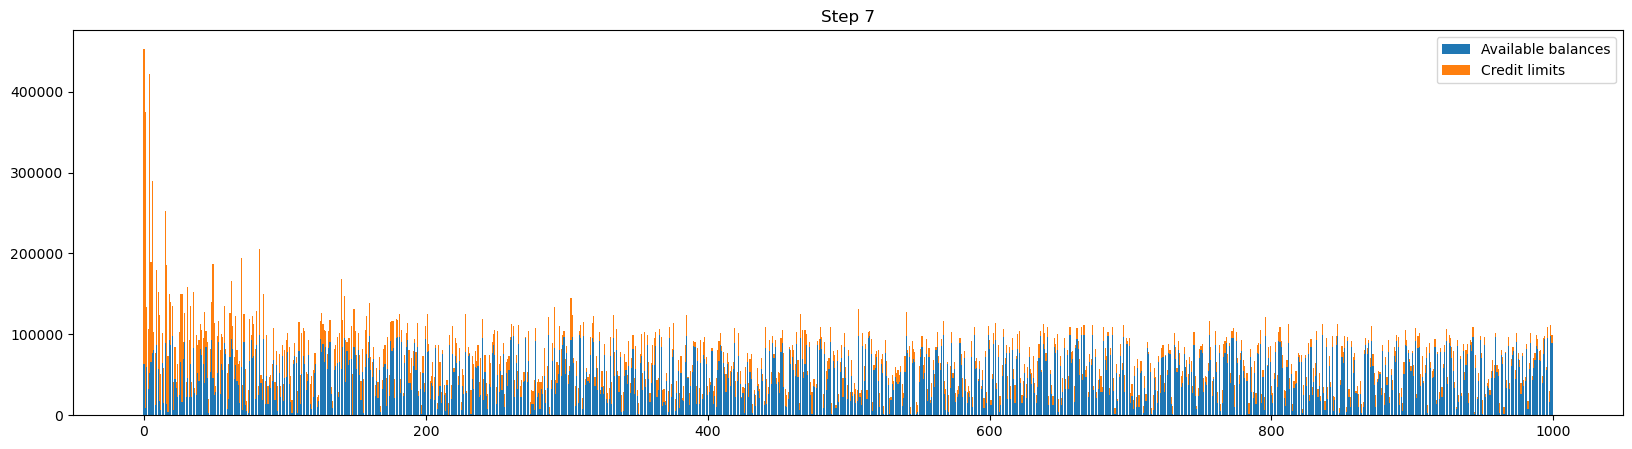

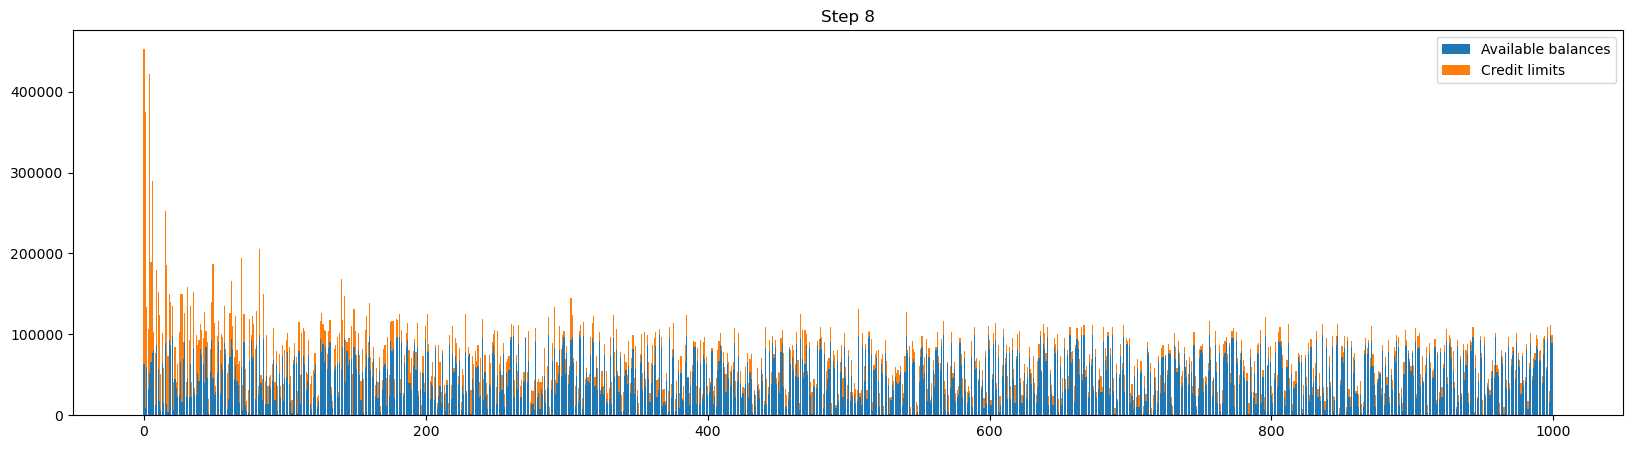

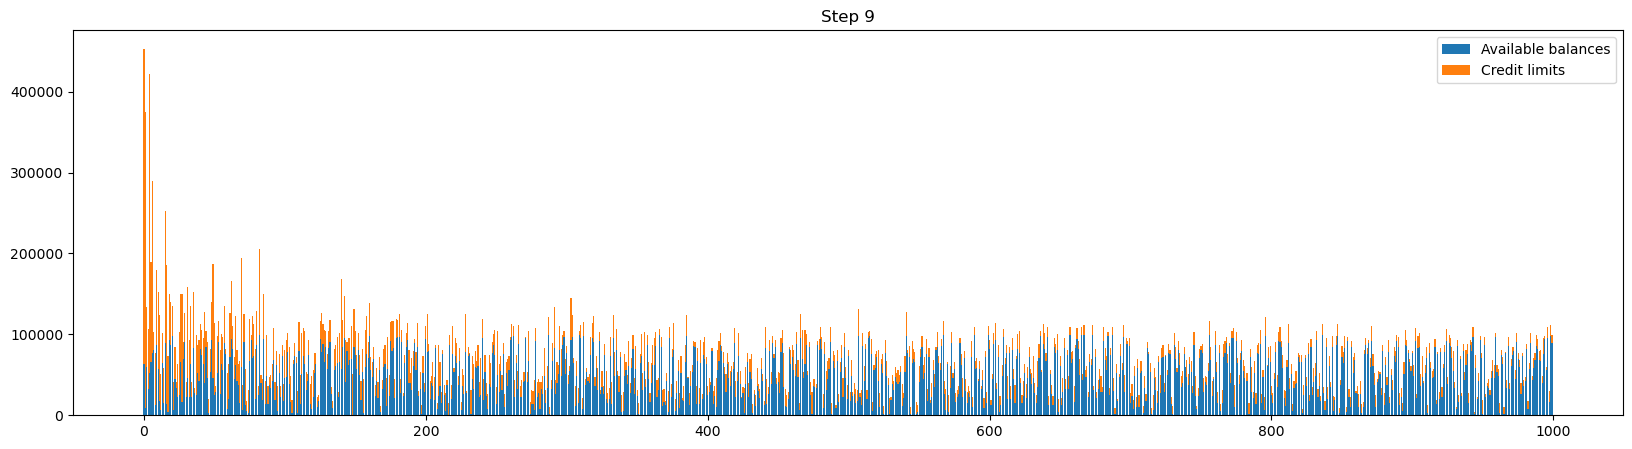

In [ ]:
for i, step in enumerate(records[0]):
    G = step["graph"]
    bs, ls = graph_balances_and_credit_limits(G)
    
    fig = plt.figure(figsize=(20, 5))
    plt.title(f"Step {i}")
    plot_balances_and_credit_limits(bs, ls)